---

# Customer Segmentation with K-Means Clustering

K-Means is an unsupervised clustering algorithm that partitions data into a fixed number of clusters by iteratively assigning points to the nearest centroid and updating centroids based on the mean of assigned points. Unlike DBSCAN, K-Means requires specifying the number of clusters in advance.

In this notebook, we apply K-Means to the Mall Customer dataset to segment customers based on their annual income and spending score. We also use the elbow method to determine the optimal number of clusters.

---

In [1]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn KMeans and preprocessing tools
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

---

## Loading and Exploring the Data

---

In [2]:
# Load the Mall Customer dataset
df = pd.read_csv("Mall_Customers.csv")

# Check dimensions and preview
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


---

## Selecting Features and Scaling

We cluster on Annual Income and Spending Score, then standardize so neither feature dominates the distance calculations.

---

In [4]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (200, 2)


---

## Finding the Optimal Number of Clusters — The Elbow Method

Before running K-Means we need to choose k, the number of clusters. The elbow method runs K-Means for a range of k values and plots the inertia (sum of squared distances from each point to its assigned centroid). The optimal k is where the inertia starts decreasing more slowly — the "elbow" of the curve.

---

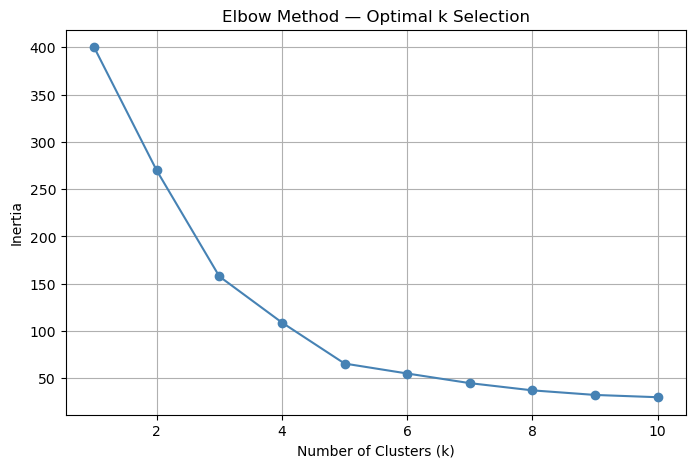

In [5]:
# Compute inertia for k = 1 to 10
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', color='steelblue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Optimal k Selection")
plt.grid(True)
plt.show()

---

## Applying K-Means

Based on the elbow curve, k=5 appears to be the optimal number of clusters. Let's fit K-Means with k=5 and visualize the results.

---

In [6]:
# Fit K-Means with k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

print(f"Number of clusters: {len(np.unique(labels))}")
print(f"Cluster distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

Number of clusters: 5
Cluster distribution: {np.int32(0): np.int64(81), np.int32(1): np.int64(39), np.int32(2): np.int64(22), np.int32(3): np.int64(35), np.int32(4): np.int64(23)}


---

## Visualizing the Clusters

---

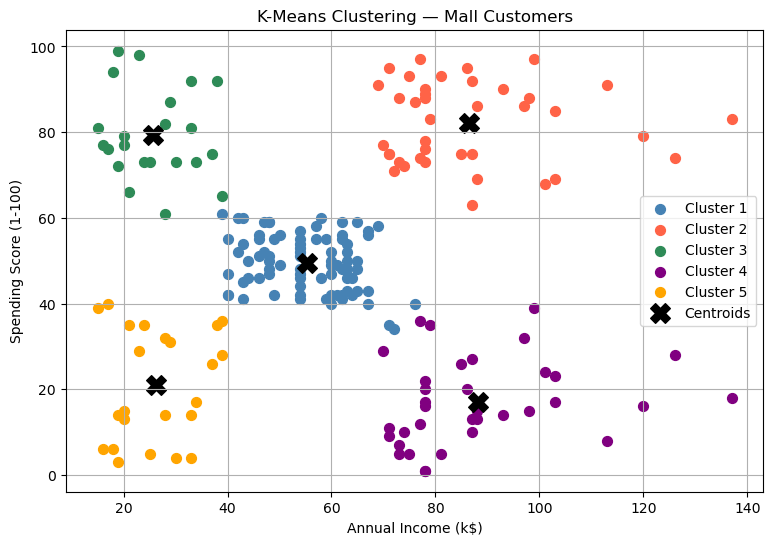

In [7]:
# Plot the clusters and centroids
plt.figure(figsize=(9, 6))
colors = ['steelblue', 'tomato', 'seagreen', 'purple', 'orange']

for i in range(5):
    mask = labels == i
    plt.scatter(X[mask, 0], X[mask, 1], color=colors[i], s=50, label=f'Cluster {i + 1}')

# Plot centroids in original scale
centroids_original = scaler.inverse_transform(centroids)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', marker='X', s=200, label='Centroids')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering — Mall Customers")
plt.legend()
plt.grid(True)
plt.show()

---

## Interpreting the Clusters

Let's look at the average income and spending score for each cluster to understand what each group represents.

---

In [8]:
# Add cluster labels to the original dataframe
df['Cluster'] = labels

# Compute average income and spending score per cluster
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean().round(1)
cluster_summary.index = [f'Cluster {i+1}' for i in range(5)]
print(cluster_summary)

           Annual Income (k$)  Spending Score (1-100)   Age
Cluster 1                55.3                    49.5  42.7
Cluster 2                86.5                    82.1  32.7
Cluster 3                25.7                    79.4  25.3
Cluster 4                88.2                    17.1  41.1
Cluster 5                26.3                    20.9  45.2


---

Based on the cluster averages, we can identify five distinct customer segments:

- **Cluster 1** — Middle income, average spending, older customers. The largest group representing typical shoppers.
- **Cluster 2** — High income, high spending. The most valuable customer segment for the mall.
- **Cluster 3** — Low income, high spending. Young customers who spend beyond their means.
- **Cluster 4** — High income, low spending. Wealthy but conservative spenders — an untapped opportunity.
- **Cluster 5** — Low income, low spending. Budget-conscious older customers.

---

---

## Summary

In this notebook we applied K-Means clustering to segment mall customers based on annual income and spending score. Using the elbow method we identified 5 as the optimal number of clusters, revealing distinct customer personas ranging from high-value spenders to budget-conscious shoppers.

Key takeaways:
- K-Means requires specifying the number of clusters in advance unlike DBSCAN
- The elbow method is a practical way to choose the optimal k
- Standardizing features before clustering is essential since K-Means relies on distance
- The resulting clusters have clear real-world interpretations useful for targeted marketing

---